## 1. Load Datasets and Intial Glance

In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")

# Basic Info
display(df.shape)
display(df.head())
display(df.info())

(891, 15)

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


None

**Interpretation:**
- This gives you ~891 sample × 15 features.
- data types are numeric, categorical, and boolean — e.g. age, fare, sex, class, survived, etc.

## 2. Check for Missing values

In [9]:
display(df.isna().sum())

survived         0
pclass           0
sex              0
age            177
sibsp            0
parch            0
fare             0
embarked         2
class            0
who              0
adult_male       0
deck           688
embark_town      2
alive            0
alone            0
dtype: int64

- We can notice that age, embarked and deck contians some missing value.
- Statistically, these represent incomplete observations — reducing sample size and potentially biasing inference.

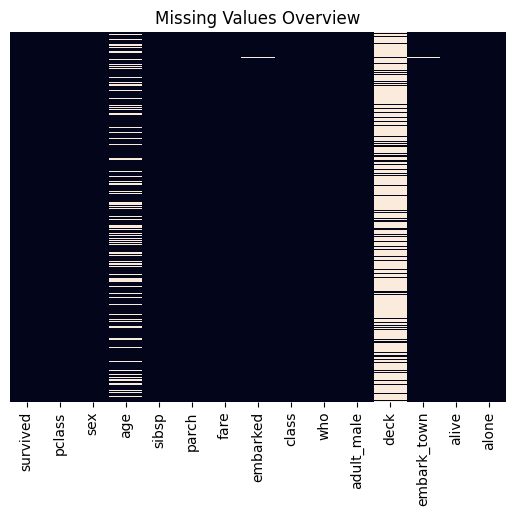

In [10]:
sns.heatmap(df.isnull(), cbar=False, yticklabels=False)
plt.title("Missing Values Overview")
plt.show()

## 3. Univariate Analysis (Single Feature)

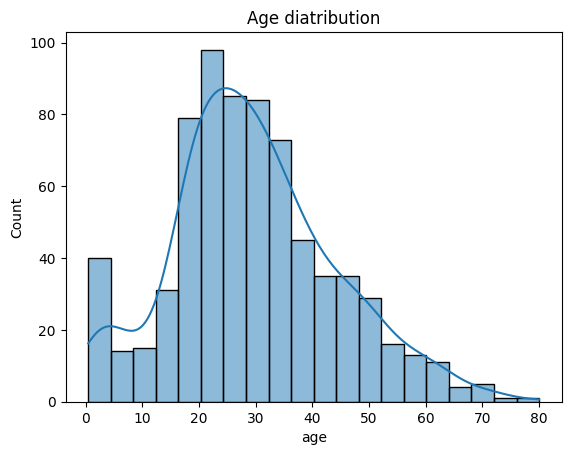

In [14]:
sns.histplot(data=df["age"], kde=True)
plt.title("Age diatribution")
plt.show()

**Interpretation:**

* The KDE (Kernel Density Estimation) curve represents the **probability density function** — a continuous approximation of the histogram.
* Check if the distribution is symmetric or skewed.
* If it’s right-skewed → many younger passengers, few elderly.

## 4. Bivariate Analysis (Two Features)

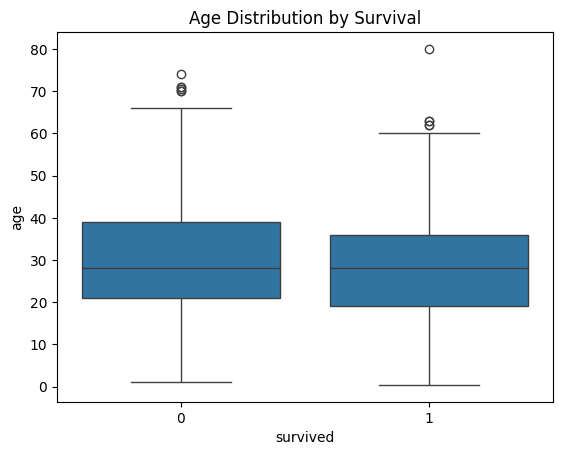

In [15]:
sns.boxplot(data=df, x="survived", y = "age")
plt.title("Age Distribution by Survival")
plt.show()

**Interpretation:**

* Boxplots visualize **quartiles and outliers**.
* You may find that younger passengers had higher survival rates — a statistical hint that age could be an important predictor.

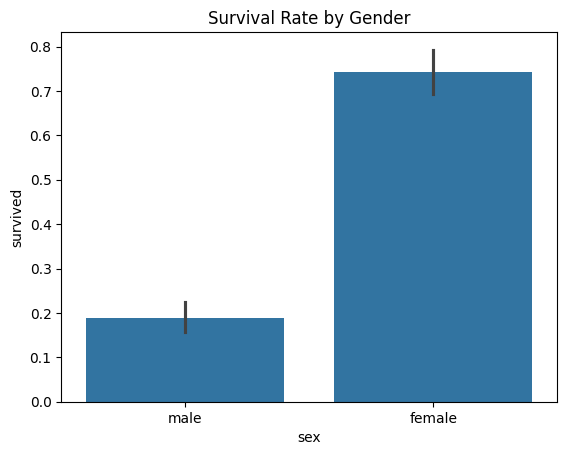

In [21]:
sns.barplot(data=df, x="sex", y="survived")
plt.title("Survival Rate by Gender")
plt.show()

**Interpretation:**

* You’ll likely see that females had a higher survival probability.
* Statistically, this shows a **conditional probability** effect:
  $$( P(\text{Survived} | \text{Sex} = \text{female}) > P(\text{Survived} | \text{Sex} = \text{male}) )$$

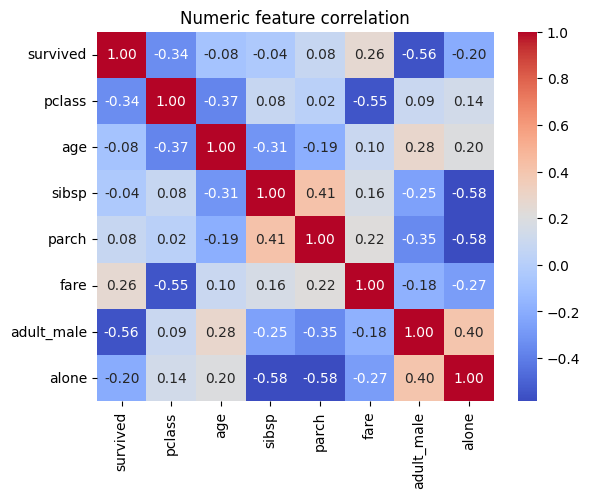

In [23]:
corr = df.corr(numeric_only=True)
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt="0.2f")
plt.title("Numeric feature correlation")
plt.show()

**Interpretation:**
Look for:

* High positive correlation (e.g., `fare` and `pclass` are inversely related)
* Weak correlations with `survived` → might mean relationships are nonlinear or categorical.

## 5. Real-World Relevance

* EDA uncovers **bias** (e.g., gender, class survival difference).
* Helps decide which features need **encoding, normalization, or transformation**.
* Prevents model overfitting by revealing **redundant variables**.
* Forms your first hypothesis: *which variables really matter for prediction?*

## 🧠 Exercise 2

1. Load the Titanic dataset (`sns.load_dataset('titanic')`).

2. Do the following:

   * Plot **Fare Distribution** using a histogram + KDE.
   * Create a **boxplot of Fare vs Class**.
   * Interpret what these visuals tell you about income disparity across classes.
   * (Optional: calculate mean and std deviation of fare per class.)

3. Write a short **2–3 sentence interpretation** of your results:

   * What pattern do you observe?
   * What does it imply statistically?

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    object  
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    object  
 8   class        891 non-null    category
 9   who          891 non-null    object  
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    object  
 13  alive        891 non-null    object  
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), object(5)
memory usage: 80.7+ KB


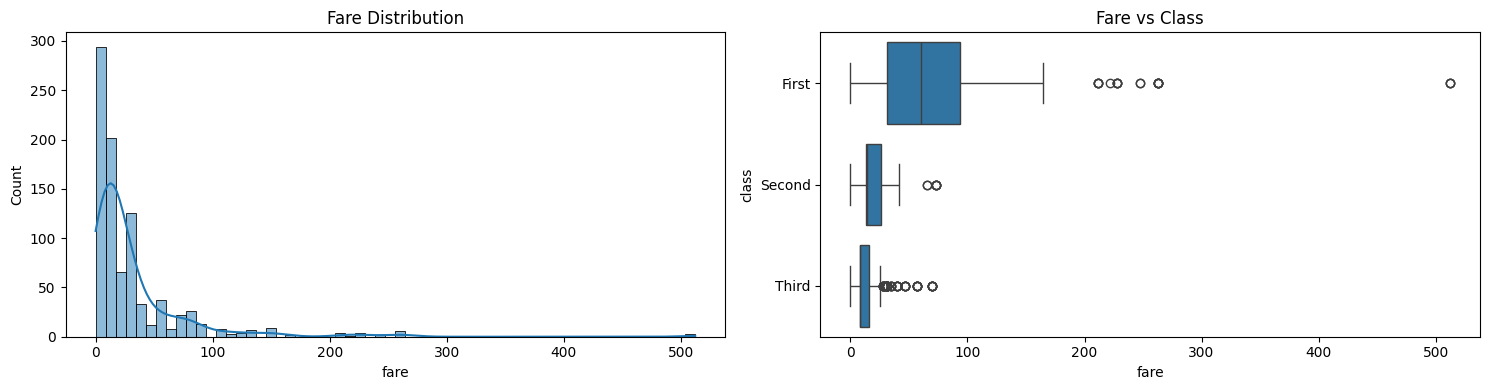

class
First     84.154687
Second    20.662183
Third     13.675550
Name: fare, dtype: float64
class
First     78.380373
Second    13.417399
Third     11.778142
Name: fare, dtype: float64


C:\Users\DheerajKarki\AppData\Local\Temp\ipykernel_23584\3103954070.py:20: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("class")["fare"].mean())
C:\Users\DheerajKarki\AppData\Local\Temp\ipykernel_23584\3103954070.py:22: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  print(df.groupby("class")["fare"].std())


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

df = sns.load_dataset("titanic")
df.info()

fig, axes = plt.subplots(1,2, figsize=(15,4))

sns.histplot(data=df["fare"], kde=True, ax=axes[0])
axes[0].set_title("Fare Distribution")

sns.boxplot(data=df, x="fare", y="class", ax=axes[1])
axes[1].set_title("Fare vs Class")

plt.tight_layout()
plt.show()

print(df.groupby("class")["fare"].mean())

print(df.groupby("class")["fare"].std())

# Pattern Observed
# - Fare is right skewed i.e. there are more people who payed less in compare to high payed customer
# - Higher the class higher the ticker fare